# Brent-WTI Hedge Ratio During Crude-Oil Event Windows

This notebook summarizes the hedge-ratio robustness check on short periods when crude oil prices moved sharply. Each window uses Databento `GLBX.MDP3` continuous futures, 1-minute bars, for `CL.v.0` and `BZ.v.0`.

**Question:** do event windows justify replacing the static 1:1 Brent-WTI spread with a fitted hedge ratio?

**Answer:** no. The evidence still supports using the simple `CL - BZ` spread as the primary strategy input.

## Method

For each six-day window:

1. Pull `ohlcv-1m` bars for continuous front-month `CL.v.0` and `BZ.v.0`.
2. Align both contracts on the 1-minute timestamp.
3. Construct the static spread: `CL close - BZ close`.
4. Estimate a level regression: `CL = alpha + beta * BZ`.
5. Estimate a return regression: `diff(CL) = alpha + beta * diff(BZ)`.
6. Compare the fitted residual volatility against the simple 1:1 spread.

In [1]:
from pathlib import Path
import os
import tempfile

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mplconfig-"))

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "_output").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_PATH = PROJECT_ROOT / "_output" / "event_windows" / "hedge_ratio_event_windows.csv"
DATA_DIR = PROJECT_ROOT / "_data" / "event_windows"

results = pd.read_csv(RESULTS_PATH)
results

Matplotlib is building the font cache; this may take a moment.


,window,description,start,end_exclusive,rows,cl_start,cl_end,bz_start,bz_end,level_alpha,level_beta,level_r2,return_beta,return_r2,corr_levels,corr_returns,spread_mean,spread_std,spread_min,spread_max,ols_resid_std,ols_std_improvement_vs_1to1
0,covid_negative_wti,COVID shock / WTI negative-price week,2020-04-17,2020-04-23,4707,19.99,14.49,28.91,20.93,-4.093631,0.910342,0.729519,0.913122,0.293248,0.854119,0.541524,-6.239720,2.249301,-11.31,-2.16,2.220443,0.012830
1,covid_vaccine_reopen,COVID vaccine/reopening repricing,2020-11-06,2020-11-12,4355,38.39,41.57,40.62,43.85,-2.424883,1.004823,0.998581,0.872648,0.780340,0.999290,0.883368,-2.221111,0.067239,-2.37,-2.05,0.066701,0.008008
2,russia_ukraine_invasion,Russia-Ukraine invasion shock,2022-02-24,2022-03-02,3929,92.79,106.41,97.69,107.35,-4.408565,1.007089,0.728137,0.916617,0.593290,0.853309,0.770253,-3.693446,1.763361,-7.14,-0.82,1.763244,0.000066
3,non_conflict_baseline_2023,Baseline week without a major new global confl...,2023-05-08,2023-05-14,4858,71.35,70.09,75.29,74.14,-11.991578,1.106621,0.994024,0.884730,0.805899,0.997007,0.897719,-3.879286,0.124229,-4.17,-3.61,0.077886,0.373048
4,iran_israel_april_2024,Iran-Israel April 2024 escalation,2024-04-12,2024-04-18,4031,85.45,82.72,90.11,87.38,-4.148949,0.994147,0.988918,0.907560,0.788000,0.994443,0.887693,-4.674800,0.096872,-5.03,-4.43,0.096723,0.001543
5,iran_israel_june_2025,Iran-Israel June 2025 escalation,2025-06-13,2025-06-19,5116,69.50,73.36,70.78,76.51,7.418267,0.866772,0.675137,0.980941,0.869396,0.821667,0.932414,-2.546968,0.808020,-3.28,-0.82,0.788885,0.023681


## Windows Tested

These windows were chosen to capture crude-oil stress or repricing regimes: COVID shock, reopening/vaccine repricing, Russia-Ukraine invasion, Iran-Israel escalation periods, plus one calmer baseline week without a major new global conflict shock.

In [2]:
window_table = results[["description", "start", "end_exclusive", "rows", "cl_start", "cl_end", "bz_start", "bz_end"]].copy()
window_table[["cl_start", "cl_end", "bz_start", "bz_end"]] = window_table[["cl_start", "cl_end", "bz_start", "bz_end"]].round(2)
window_table

,description,start,end_exclusive,rows,cl_start,cl_end,bz_start,bz_end
0,COVID shock / WTI negative-price week,2020-04-17,2020-04-23,4707,19.99,14.49,28.91,20.93
1,COVID vaccine/reopening repricing,2020-11-06,2020-11-12,4355,38.39,41.57,40.62,43.85
2,Russia-Ukraine invasion shock,2022-02-24,2022-03-02,3929,92.79,106.41,97.69,107.35
3,Baseline week without a major new global confl...,2023-05-08,2023-05-14,4858,71.35,70.09,75.29,74.14
4,Iran-Israel April 2024 escalation,2024-04-12,2024-04-18,4031,85.45,82.72,90.11,87.38
5,Iran-Israel June 2025 escalation,2025-06-13,2025-06-19,5116,69.50,73.36,70.78,76.51


## Hedge-Ratio Diagnostics

The most relevant number for sizing a market-neutral futures spread is the **return beta**, because it measures co-movement in price changes. A return beta near 1 supports the static 1:1 construction.

The level beta is useful as a fair-value regression check, but a level fit can be unstable in short event windows and can look better in-sample without improving the tradable spread.

In [3]:
diagnostics = results[[
    "description",
    "return_beta",
    "level_beta",
    "return_r2",
    "level_r2",
    "corr_returns",
    "corr_levels",
    "spread_std",
    "ols_resid_std",
    "ols_std_improvement_vs_1to1",
]].copy()

round_cols = diagnostics.columns.drop("description")
diagnostics[round_cols] = diagnostics[round_cols].round(4)
diagnostics

,description,return_beta,level_beta,return_r2,level_r2,corr_returns,corr_levels,spread_std,ols_resid_std,ols_std_improvement_vs_1to1
0,COVID shock / WTI negative-price week,0.9131,0.9103,0.2932,0.7295,0.5415,0.8541,2.2493,2.2204,0.0128
1,COVID vaccine/reopening repricing,0.8726,1.0048,0.7803,0.9986,0.8834,0.9993,0.0672,0.0667,0.0080
2,Russia-Ukraine invasion shock,0.9166,1.0071,0.5933,0.7281,0.7703,0.8533,1.7634,1.7632,0.0001
3,Baseline week without a major new global confl...,0.8847,1.1066,0.8059,0.9940,0.8977,0.9970,0.1242,0.0779,0.3730
4,Iran-Israel April 2024 escalation,0.9076,0.9941,0.7880,0.9889,0.8877,0.9944,0.0969,0.0967,0.0015
5,Iran-Israel June 2025 escalation,0.9809,0.8668,0.8694,0.6751,0.9324,0.8217,0.8080,0.7889,0.0237


## Visual Summary

The key checks are: return beta near 1, level beta stability, and whether a fitted level regression meaningfully reduces residual volatility versus the simple `CL - BZ` spread.

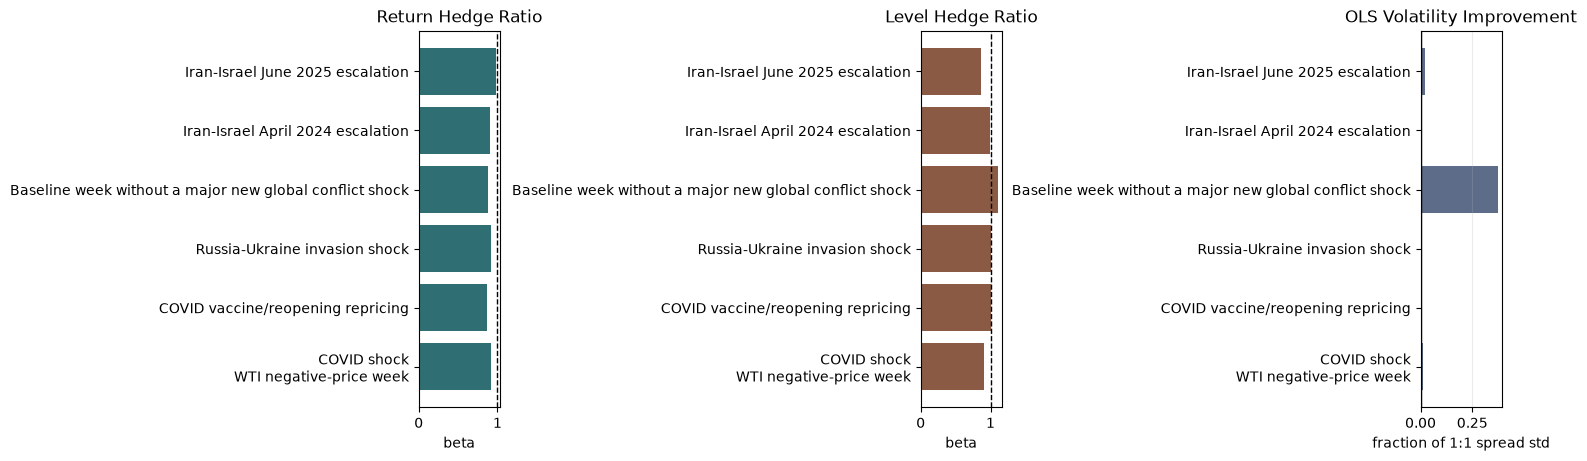

In [4]:
plot_df = results.copy()
plot_df["label"] = plot_df["description"].str.replace(" / ", "\n", regex=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

axes[0].barh(plot_df["label"], plot_df["return_beta"], color="#2F6F73")
axes[0].axvline(1.0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Return Hedge Ratio")
axes[0].set_xlabel("beta")

axes[1].barh(plot_df["label"], plot_df["level_beta"], color="#8A5A44")
axes[1].axvline(1.0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Level Hedge Ratio")
axes[1].set_xlabel("beta")

axes[2].barh(plot_df["label"], plot_df["ols_std_improvement_vs_1to1"], color="#5D6C89")
axes[2].axvline(0.0, color="black", linewidth=1)
axes[2].set_title("OLS Volatility Improvement")
axes[2].set_xlabel("fraction of 1:1 spread std")

for ax in axes:
    ax.grid(axis="x", alpha=0.25)
    ax.set_ylabel("")

plt.show()

## Static 1:1 Spread Paths

These plots show the simple `CL - BZ` spread inside each stress window. The large COVID negative-WTI episode is visibly different from the later windows, but the fitted hedge-ratio tests still do not provide strong evidence for replacing the 1:1 construction.

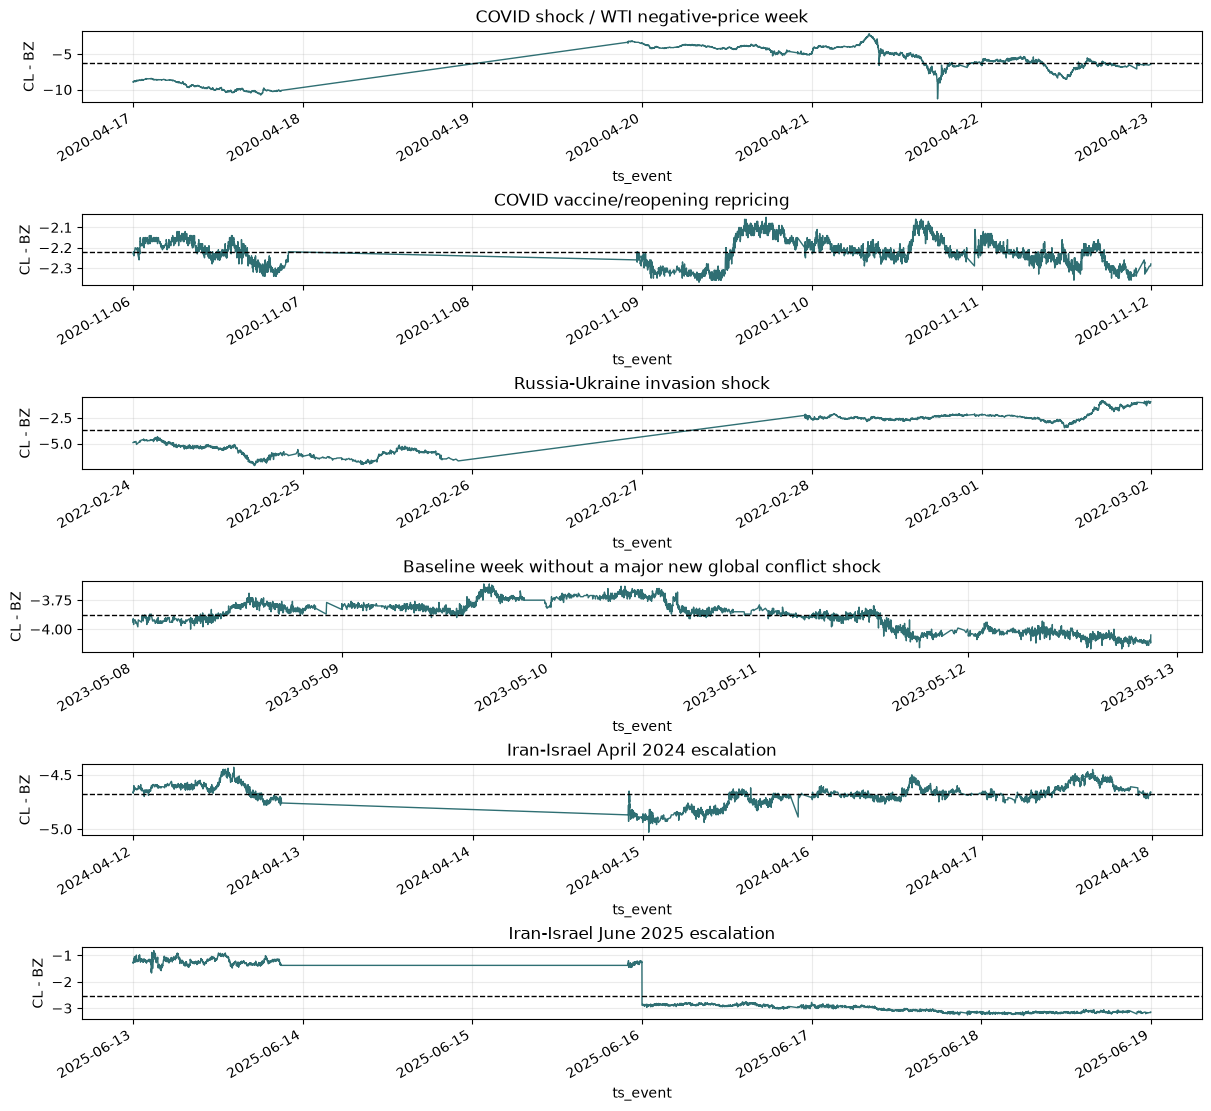

In [5]:
fig, axes = plt.subplots(len(results), 1, figsize=(12, 11), sharex=False, constrained_layout=True)

for ax, row in zip(axes, results.itertuples(index=False)):
    path = DATA_DIR / f"{row.window}_cl_bz_1m_{row.start}_{row.end_exclusive}.parquet"
    df = pd.read_parquet(path)
    df["synth_mid"].plot(ax=ax, color="#2F6F73", linewidth=1)
    ax.axhline(df["synth_mid"].mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(row.description)
    ax.set_ylabel("CL - BZ")
    ax.grid(alpha=0.25)

plt.show()

## Conclusion

The event-window results support keeping the Brent-WTI strategy on a static **1:1 spread**.

- Return betas are mostly close to 1, ranging from roughly 0.87 to 0.98 across the selected windows.
- Level betas move around more, especially in short crisis samples, which makes them less attractive as a production hedge ratio.
- In most windows, OLS residuals reduce in-sample spread volatility by very little versus the 1:1 spread.
- The non-conflict baseline has a larger in-sample OLS volatility improvement, but that is one short sample and does not outweigh the simpler futures contract logic of `CL - BZ`.

**Final decision:** use `CL - BZ` as the main spread. Treat fitted hedge ratios as robustness diagnostics, not as the primary construction.